Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Read merged data

In [2]:
merged_data = pd.read_csv("../../data/processed/merged_clean.csv")

Subset data for subgroup: 
Per_Level_Label = ["B2.1", "B2.2", "C1"]
Prof_Use_Label = "Yes"

In [3]:
subgroup = merged_data[
    (merged_data["Per_Level_Label"].isin(["B2.1", "B2.2", "C1"])
    ) & (merged_data["Prof_Use_Label"] == "Yes")      
]

Subgroup validation

In [4]:
subgroup.shape

(198, 31)

In [5]:
subgroup.columns

Index(['Participant_ID', 'Focus', 'Agent', 'Goal_Type', 'Item', 'Item_string',
       'Item_len', 'Response_tag', 'Response', 'Response_Full', 'EXP', 'n',
       'Age', 'Gender', 'Kno_Level', 'Per_Level', 'Bilingual', 'Bi_Parents',
       'Multi_Kno', 'Multi_Spk', 'Immersion', 'Prof_Need', 'Prof_Use',
       'Motivation', 'Distractor', 'GN_Score', 'Difficulty', 'Kno_Level_Label',
       'Per_Level_Label', 'Prof_Need_Label', 'Prof_Use_Label'],
      dtype='str')

In [6]:
subgroup.duplicated().sum()

np.int64(0)

In [7]:
subgroup.head()

,Participant_ID,Focus,Agent,Goal_Type,Item,Item_string,Item_len,Response_tag,Response,Response_Full,...,Prof_Need,Prof_Use,Motivation,Distractor,GN_Score,Difficulty,Kno_Level_Label,Per_Level_Label,Prof_Need_Label,Prof_Use_Label
0,EXP1_01,I,1,no_goal,Item1,"""If I had heard the rainstorm, I would have fe...",11,L1_transfer_3,L1_transfer,L1_transfer,...,1,1,4,4,23,3,B2.1,B2.2,Yes,Yes
1,EXP1_01,I,1,no_goal,Item2,"""If I had climbed the mountain cliff, I would ...",12,L1_transfer_3,L1_transfer,L1_transfer,...,1,1,4,4,23,3,B2.1,B2.2,Yes,Yes
2,EXP1_01,I,1,goal_non_frequent,Item1,"""If I had created an online platform, I would ...",14,L1_transfer_3,L1_transfer,L1_transfer,...,1,1,4,4,23,3,B2.1,B2.2,Yes,Yes
3,EXP1_01,I,1,goal_non_frequent,Item2,"""If I had invested in technology, I would have...",13,correct_3,correct,correct,...,1,1,4,4,23,3,B2.1,B2.2,Yes,Yes
4,EXP1_01,I,1,goal_frequent,Item1,"""If I had saved money, I would have gone on ho...",11,correct_3,correct,correct,...,1,1,4,4,23,3,B2.1,B2.2,Yes,Yes


Overall response distribution

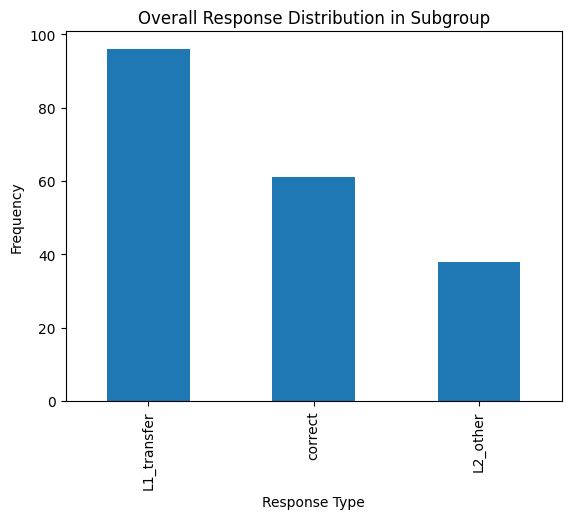

In [8]:
subgroup["Response_Full"].value_counts().plot(kind = "bar")

plt.title("Overall Response Distribution in Subgroup")
plt.xlabel("Response Type")
plt.ylabel("Frequency")

plt.show()

Goal_Type response distribution in Subgroup

Response counts and proportions by Goal_Type

In [9]:
goal_response_counts = pd.crosstab(
    subgroup["Goal_Type"],
    subgroup["Response_Full"]
)

goal_response_counts

Response_Full,L1_transfer,L2_other,correct
Goal_Type,,,
goal_frequent,25,16,24
goal_non_frequent,37,10,19
no_goal,34,12,18


In [10]:
goal_response_props = pd.crosstab(
    subgroup["Goal_Type"],
    subgroup["Response_Full"],
    normalize="index"
)

goal_response_props

Response_Full,L1_transfer,L2_other,correct
Goal_Type,,,
goal_frequent,0.384615,0.246154,0.369231
goal_non_frequent,0.560606,0.151515,0.287879
no_goal,0.531250,0.187500,0.281250


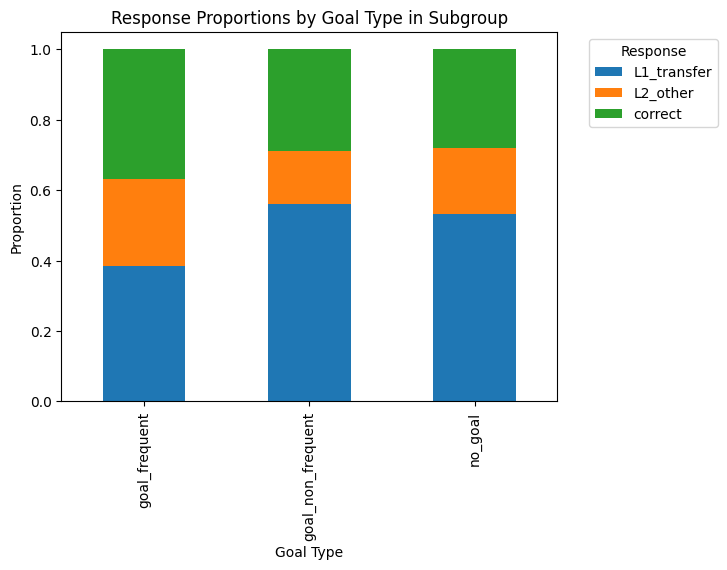

In [11]:
goal_response_props.plot(kind="bar", stacked=True)

plt.title("Response Proportions by Goal Type in Subgroup")
plt.xlabel("Goal Type")
plt.ylabel("Proportion")
plt.legend(title="Response", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.show()

Agent response distribution in Subgroup

Response counts and proportions by Agent

In [12]:
agent_response_counts = pd.crosstab(
    subgroup["Agent"],
    subgroup["Response_Full"]
)

agent_response_counts

Response_Full,L1_transfer,L2_other,correct
Agent,,,
0,57,31,35
1,39,7,26


In [13]:
agent_response_props = pd.crosstab(
    subgroup["Agent"],
    subgroup["Response_Full"],
    normalize="index"
)

agent_response_props

Response_Full,L1_transfer,L2_other,correct
Agent,,,
0,0.463415,0.252033,0.284553
1,0.541667,0.097222,0.361111


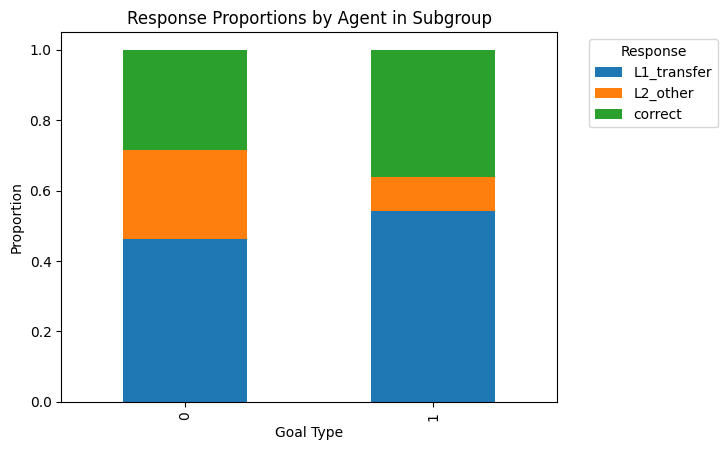

In [14]:
agent_response_props.plot(kind= "bar", stacked= True)

plt.title("Response Proportions by Agent in Subgroup")
plt.xlabel("Goal Type")
plt.ylabel("Proportion")
plt.legend(title="Response", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.show()

Goal_Type X Agent response distribution in Subgroup

Response proportions by Goal_Type and by Agent

In [15]:
goal_agent_response_props = pd.crosstab(
    [subgroup["Goal_Type"], subgroup["Agent"]],
    subgroup["Response_Full"],
    normalize="index"
)

goal_agent_response_props

Response_Full            L1_transfer  L2_other   correct
Goal_Type         Agent                                 
goal_frequent     0         0.317073  0.341463  0.341463
                  1         0.500000  0.083333  0.416667
goal_non_frequent 0         0.500000  0.214286  0.285714
                  1         0.666667  0.041667  0.291667
no_goal           0         0.575000  0.200000  0.225000
                  1         0.458333  0.166667  0.375000

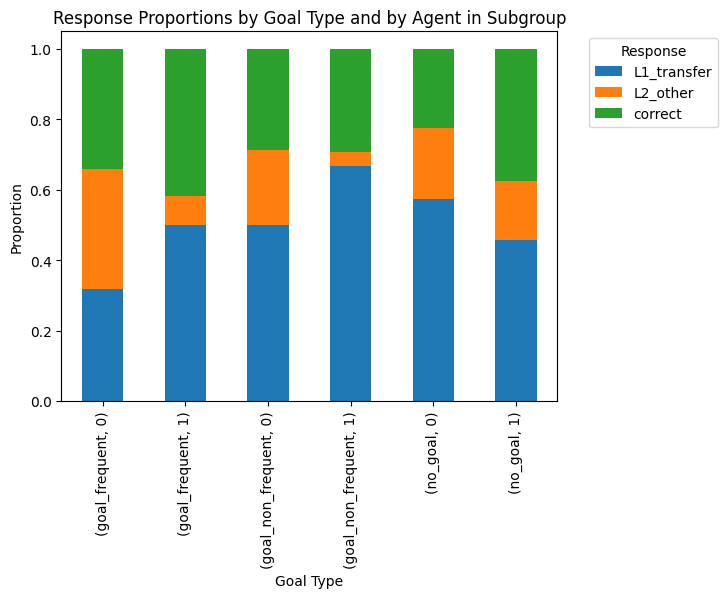

In [16]:
goal_agent_response_props.plot(kind="bar", stacked= True)

plt.title("Response Proportions by Goal Type and by Agent in Subgroup")
plt.xlabel("Goal Type")
plt.ylabel("Proportion")
plt.legend(title="Response", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.show()